# Timeline sanity checks (Phase 2)

Checks that the match timelines from `scripts/build_timeline.py` behave sensibly:

1. Coverage: how many sampled frames are computed, and why the rest are skipped.
2. One match over time (IDSSE J03WMX, CC BY 4.0), per team, with goals marked.
3. **Turnovers**: xSpace should spike right after possession is won in open play.
4. **Set pieces** are excluded; defensive-shape columns are physically plausible.
5. Team-match averages: created vs conceded.

Frame-level plots use IDSSE only; PFF appears only in aggregates (terms still under review).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xspace.config import TIMELINE_DIR
from xspace.metrics.timeline import read_timeline
from xspace.pipeline import prepare_match

frames, meta = [], {}
for path in sorted(TIMELINE_DIR.glob("*.parquet")):
    df, m = read_timeline(path)
    df.insert(0, "source", m["source"])
    df.insert(1, "match_id", m["match_id"])
    frames.append(df)
    meta[(m["source"], m["match_id"])] = m
tl = pd.concat(frames, ignore_index=True)
print(f"{len(meta)} matches, {len(tl):,} sampled frames; params hashes:",
      sorted({m['params_hash'] for m in meta.values()}))

71 matches, 1,278,653 sampled frames; params hashes: ['89404c61b49c']


## 1. Coverage

In [2]:
(tl.groupby("source")["status"].value_counts(normalize=True).unstack().mul(100).round(1))

status,ok,quality,no_possession,set_piece
source,,,,
idsse,85.6,0.1,0.0,14.3
pff,82.4,6.4,0.0,11.3


## 2. One match over time

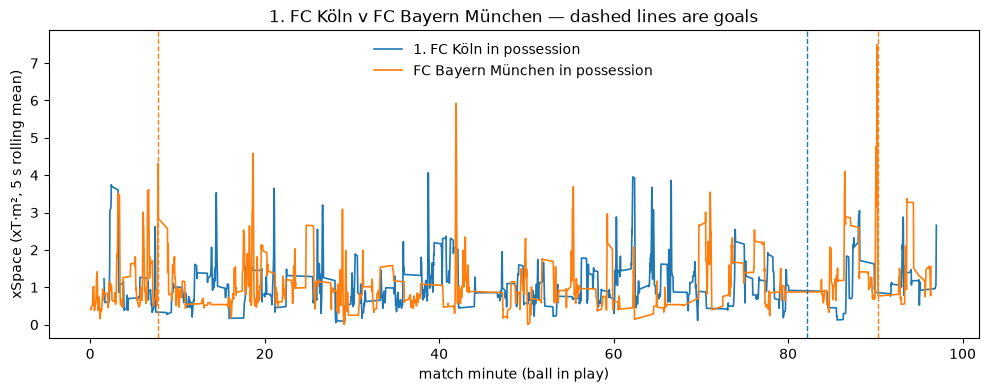

In [3]:
SOURCE, MATCH = "idsse", "J03WMX"
m = meta[(SOURCE, MATCH)]
one = tl[(tl.source == SOURCE) & (tl.match_id == MATCH)].copy()
pm = prepare_match(SOURCE, MATCH)
ev = pm.events
goals = ev[(ev["type"] == "shot") & ev["outcome"].isin(["G", "GOAL"]) & (ev["frame"] >= 0)]

# Match clock in minutes: periods laid end to end.
period_len = one.groupby("period")["time_s"].max()
offset = period_len.cumsum().shift(fill_value=0)
one["minute"] = (one["time_s"] + one["period"].map(offset)) / 60
gm = (pm.match.timestamp[goals["frame"]] + goals["period"].map(offset).to_numpy()) / 60

fig, ax = plt.subplots(figsize=(12, 4))
for side, name, colour in ((0, m["home"], "tab:blue"), (1, m["away"], "tab:orange")):
    s = one[(one.status == "ok") & (one.possession_side == side)].set_index("minute")["total"]
    ax.plot(s.index, s.rolling(25, min_periods=5).mean(), color=colour, lw=1.2,
            label=f"{name} in possession")
for x, side in zip(gm, goals["team_side"], strict=True):
    ax.axvline(x, color="tab:blue" if side == 0 else "tab:orange", ls="--", lw=1)
ax.set(xlabel="match minute (ball in play)", ylabel="xSpace (xT·m², 5 s rolling mean)",
       title=f"{m['home']} v {m['away']} — dashed lines are goals")
ax.legend(frameon=False)
plt.show()

## 3. Turnovers

Align every possession on its first frame and average xSpace by seconds since the start, split
into possessions won in open play (transitions) and those starting from a restart. If xSpace
captures disorganised defences, space *behind* the defence should be higher just after a
turnover. Ball position confounds raw averages (turnovers happen deeper), so the table compares
transitions with settled play **within the same third**.

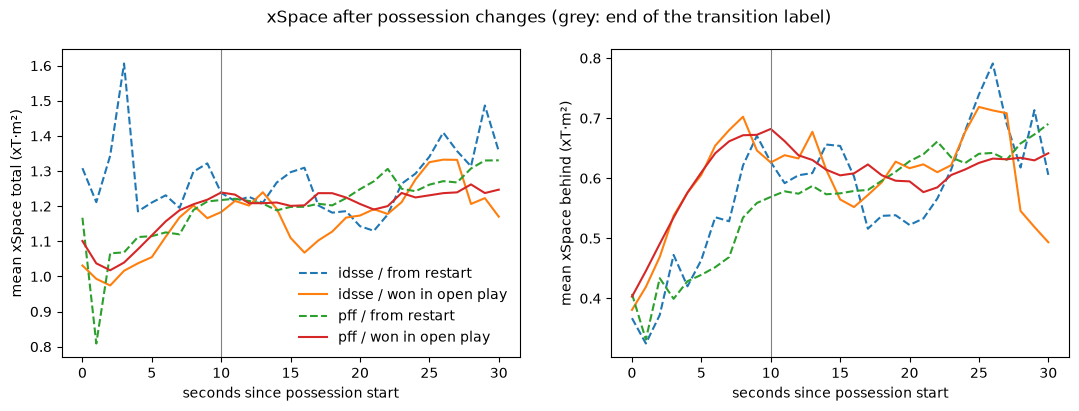

In [4]:
ok = tl[tl.status == "ok"].copy()
key = ["source", "match_id", "possession_id"]
first = tl.groupby(key)["time_s"].transform("min")
starts_transition = tl.groupby(key)["transition"].transform("first")
ok["since_start"] = (ok["time_s"] - first.loc[ok.index]).round(0)
ok["kind"] = np.where(starts_transition.loc[ok.index], "won in open play", "from restart")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["total", "behind"], strict=True):
    curve = (ok[ok.since_start <= 30].groupby(["source", "kind", "since_start"])[col]
             .mean().unstack(["source", "kind"]))
    for c in curve.columns:
        ax.plot(curve.index, curve[c], label=" / ".join(c),
                ls="-" if c[1] == "won in open play" else "--")
    ax.axvline(10, color="grey", lw=0.8)
    ax.set(xlabel="seconds since possession start", ylabel=f"mean xSpace {col} (xT·m²)")
axes[0].legend(frameon=False)
fig.suptitle("xSpace after possession changes (grey: end of the transition label)")
plt.show()

In [5]:
cols = ["total", "behind", "between", "wide", "in_front", "mean_control", "back_line",
        "compactness"]
(ok.assign(phase=np.where(ok.transition, "transition", "settled"))
   .groupby(["source", "third", "phase"], observed=True)[cols].mean().round(3))

total  behind  between   wide  in_front  \
source third     phase                                                 
idsse  defensive settled     0.878   0.033    0.137  0.069     0.639   
                 transition  0.844   0.093    0.148  0.082     0.521   
       middle    settled     1.117   0.452    0.199  0.109     0.357   
                 transition  0.969   0.529    0.190  0.092     0.158   
       final     settled     1.603   1.135    0.272  0.077     0.119   
                 transition  1.628   1.341    0.197  0.054     0.036   
pff    defensive settled     0.841   0.110    0.107  0.076     0.548   
                 transition  0.820   0.154    0.133  0.073     0.459   
       middle    settled     1.142   0.524    0.154  0.117     0.348   
                 transition  1.065   0.569    0.185  0.096     0.215   
       final     settled     1.761   1.190    0.289  0.098     0.184   
                 transition  1.817   1.372    0.261  0.086     0.098   

                             mean_control  back_line  compactness  
source third     phase                                             
idsse  defensive settled            0.453   7.872000       13.474  
                 transition         0.385   3.348000       14.365  
       middle    settled            0.587  19.313999       10.751  
                 transition         0.505  13.863000       12.048  
       final     settled            0.723  36.353001       10.003  
                 transition         0.658  31.681000       11.563  
pff    defensive settled            0.445   5.277000       12.278  
                 transition         0.350  -0.484000       13.317  
       middle    settled            0.609  19.466999        9.303  
                 transition         0.516  14.612000       10.839  
       final     settled            0.753  36.091000        7.794  
                 transition         0.695  33.243000        9.696

**Findings (2026-10-01, all 71 matches).** The expected turnover effect shows up in the
*behind* component, not the total. Within every third, and on both IDSSE and PFF, transitions
have more space behind the defence than settled play, a back line 3–6 m further from goal and a
less compact block (larger back − mid distance). Over time, space behind climbs from
≈ 0.45 to ≈ 0.75 in the first ~8 s after the ball is won, and stays above possessions from
restarts until ~15 s, as the old defence races back. Total xSpace is *not* higher in transitions,
for two reasons: transitions happen more often with the ball deep, and the team that just won
the ball controls less of the pitch (lower `mean_control`, much less `in_front` space), because
its players are still in their defensive shape. The space is there, but the attackers aren't
yet placed to claim it. Phase 3 should treat these separately (space conceded vs. space
reachable by the attack).

## 4. Set pieces excluded, shape plausible

In [6]:
assert (ok["setpiece"] == "open_play").all(), "set-piece frames were computed"
assert ok["possession_side"].ge(0).all()
checks = pd.Series({
    "back line ≥ mid line": (ok.back_line >= ok.mid_line).mean(),
    "offside line ≥ back line − 2 m": (ok.offside_line >= ok.back_line - 2).mean(),
    "block width 20–68 m": ok.block_width.between(20, 68).mean(),
    "11 v 11 on the pitch": ((ok.n_att == 11) & (ok.n_def == 11)).mean(),
}).mul(100).round(1)
checks

back line ≥ mid line              100.0
offside line ≥ back line − 2 m    100.0
block width 20–68 m                99.2
11 v 11 on the pitch               98.3
dtype: float64

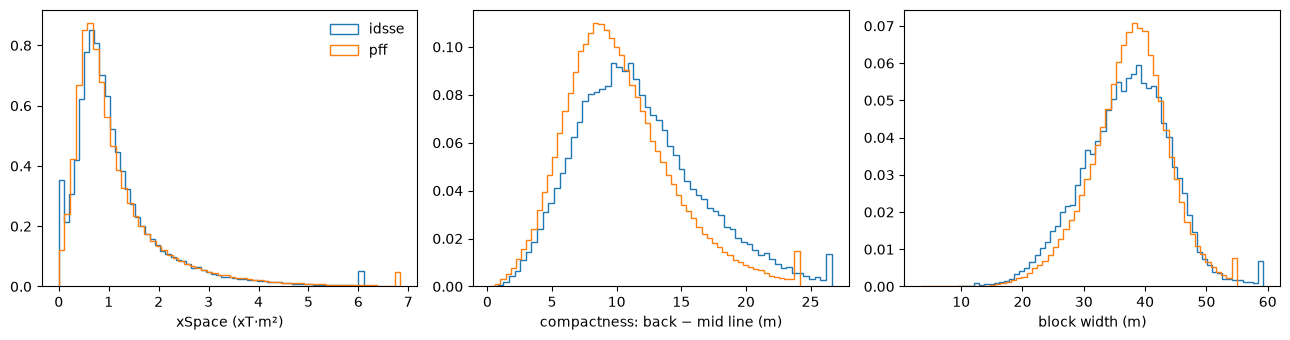

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, label in zip(axes, ["total", "compactness", "block_width"],
                          ["xSpace (xT·m²)", "compactness: back − mid line (m)",
                           "block width (m)"], strict=True):
    for source, g in ok.groupby("source"):
        ax.hist(g[col].clip(upper=g[col].quantile(0.995)), bins=60, density=True,
                histtype="step", label=source)
    ax.set(xlabel=label)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Team-match averages

Mean xSpace per computed frame when a team has the ball (*created*) and when its opponent has
the ball (*conceded*). Team names are shown for IDSSE only.

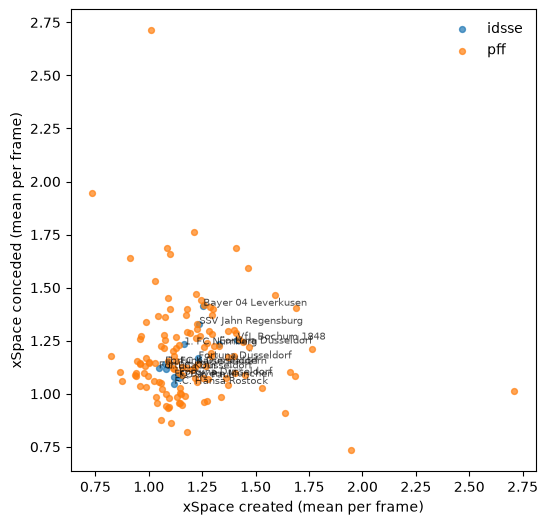

source           idsse      pff
created  count  14.000  128.000
         mean    1.175    1.195
         std     0.106    0.239
         min     1.046    0.733
         25%     1.097    1.058
         50%     1.142    1.148
         75%     1.235    1.283
         max     1.415    2.712
conceded count  14.000  128.000
         mean    1.175    1.195
         std     0.106    0.239
         min     1.046    0.733
         25%     1.097    1.058
         50%     1.142    1.148
         75%     1.235    1.283
         max     1.415    2.712


In [8]:
tm = ok.groupby(["source", "match_id", "possession_side"])["total"].mean().unstack()
tm.columns = ["home_attack", "away_attack"]
rows = []
for (source, match_id), r in tm.iterrows():
    mm = meta[(source, match_id)]
    rows.append((source, mm["home"], r.home_attack, r.away_attack))
    rows.append((source, mm["away"], r.away_attack, r.home_attack))
teams = pd.DataFrame(rows, columns=["source", "team", "created", "conceded"])
fig, ax = plt.subplots(figsize=(6, 6))
for source, g in teams.groupby("source"):
    ax.scatter(g.created, g.conceded, s=18, label=source, alpha=0.7)
for _, r in teams[teams.source == "idsse"].iterrows():
    ax.annotate(r.team, (r.created, r.conceded), fontsize=7, alpha=0.7)
ax.set(xlabel="xSpace created (mean per frame)", ylabel="xSpace conceded (mean per frame)")
ax.legend(frameon=False)
plt.show()
print(teams.groupby("source")[["created", "conceded"]].describe().round(3).T)

**Notes.** IDSSE and PFF team-match averages sit on the same scale (median ≈ 1.2), which
suggests broadcast tracking doesn't bias the level much. The clear outlier is Qatar v Netherlands
(PFF 3845; second-half median 3.2). Its frames look plausible: a narrow Dutch back line with the
far side empty. But PFF *estimates* off-camera players, and an empty far side is exactly where
that would show. That makes it a Phase 4 item (sensitivity to PFF estimated players) rather
than a pipeline bug.

This check found one real bug, now fixed: PFF extra-time periods were loaded a whole pitch
length and width off (`io.loaders.recentre_periods`).